 # Esercizio 1) Caso con $f: \mathbb{R}^2 \to \mathbb{R}$ convessa

 Considerare la funzione

   $$
   f(x_1, x_2) = (x_1-1)^2   +  2(x_2+2)^2 + 3,
   $$
   
che ha minimo nel punto $x^* =(1,-2)$.

Poi:
1. definire le funzioni python per `f` e `grad_f`;
2. calcolare il valore di $f(x^*)$ e verificare che $x^*$ è un punto stazionario di $f$;
3. visualizzare la superficie descritta da `f` nel dominio $[-3,5] \times [-6,2]$ e le curve di livello;
4. eseguire il metodo di discesa del gradiente con passo fisso, avendo definito 
    - $x_0 = (4, -1)$ come punto di partenza
    - maxit = 1000
    - $\alpha = 0.001$
    - $tol_{grad} = 1e-6$

    Calcolare la distanza (errore in norma) fra la soluzione ottenuta e $x^*$, poi creare i seguenti plot:
    - grafico con iterazioni in ascissa e valore della funzione in ordinata;
    - grafico con iterazioni in ascissa e gradiente della funzione in ordinata.
5. provare diversi valori dei parametri:
    - $\alpha = 1,\ 0.5,\ 0.1,\ 0.01,\ 0.00001$
    - $tol_{grad} = 0.1,\ 0.001$
    - altri punti di partenza $x_0$

    e tenere traccia dei risultati ottenuti (suggerimento: tabella degli errori, al variare dei parametri).
6. eseguire il metodo di discesa del gradiente con backtracking, avendo definito 
    - $x_0 = (4, -1)$ come punto di partenza
    - maxit = 1000
    - $\alpha_0 = 0.001$
7. eseguire il metodo di discesa del gradiente con backtracking, provando diversi valori di $\alpha_0$



In [65]:
import numpy as np
import matplotlib.pyplot as plt

In [57]:
#### punto 1 ########################

def f(x):
    return (x[0] - 1)**2 + 2 * (x[1] + 2)**2 + 3

def grad_f(x):
    return np.array([
        2 * (x[0] - 1),
        4 * (x[1] + 2)
    ])


In [56]:
#### punto 2 ########################

x_star = np.array( [1, -2])
print(f" f(x_star) = {f(x_star)} ")
print(f" Grad_f(x_star) = {grad_f(x_star)} ")

 f(x_star) = 3 
 Grad_f(x_star) = [0 0] 


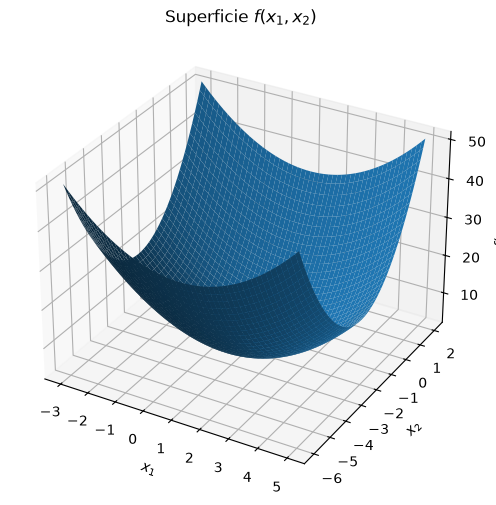

In [58]:
#### punto 3 ########################

# Costruzione della griglia
x1 = np.linspace(-3, 5, 200)
x2 = np.linspace(-6, 2, 200)
X1, X2 = np.meshgrid(x1, x2)

# Valutazione della funzione
Y = f( (X1,X2) )

# Grafico della superficie
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X1, X2, Y)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$f(x_1,x_2)$")
ax.set_title(r"Superficie $f(x_1,x_2)$")

plt.show()

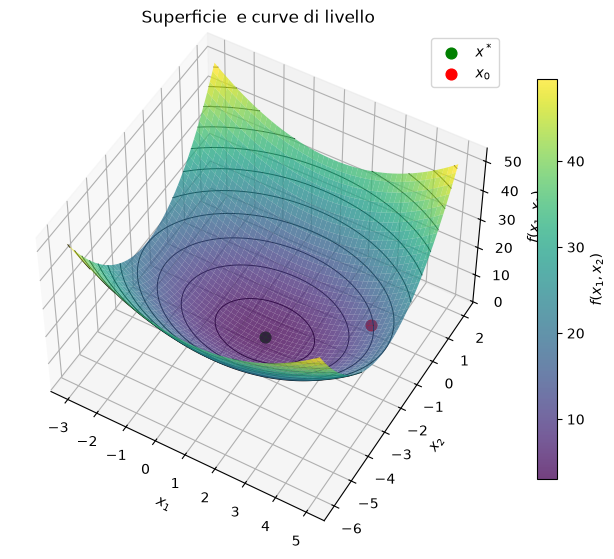

In [64]:
# Grafico della superficie
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface( X1,  X2, Y,
    cmap="viridis", alpha=0.75, edgecolor="none")

# Livelli da visualizzare (abbiamo valori indicativamente fra 0 e 50)
levels = np.linspace(1, 50, 12)

# Curve di livello sulla superficie
ax.contour( X1, X2, Y,
    levels=levels, colors="black", linewidths=0.7 )

# Punto di minimo
ax.scatter(1,-2, f( x_star),
    color="green", s=60, label=r"$x^*$"
)

# Punto di partenza
ax.scatter(4,-1, f((4,-1)),
    color="red", s=60, label=r"$x_0$"
)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_zlabel(r"$f(x_1,x_2)$")
ax.set_title("Superficie  e curve di livello")

ax.legend()
fig.colorbar(surface, ax=ax, shrink=0.65, label=r"$f(x_1,x_2)$")


ax.view_init(elev=50, azim=-60)
# ax.view_init(elev=90, azim=-90)
# ax.view_init(elev=5, azim=-60)
# ax.view_init(elev=5, azim=90)
# ax.view_init(elev=5, azim=0)
# ax.view_init(elev=50, azim=-130)

plt.show()

In [92]:
#### punto 4 ########################

def discesa_gradiente(
    f,              # funzione obiettivo
    grad_f,         # gradiente della funzione obiettivo
    x0,             # punto iniziale 
    alpha=1.0,      # lunghezza del passo, alpha>0
    tol_grad=1e-6,  # tolleranza sulla norma del gradiente
    maxit=1000      # massimo numero di iterazioni
):
    """
    Discesa del gradiente con passo fisso.
    """

    # Inizializzazioni
    x = np.asarray(x0, dtype=float).copy()

    k = 0
    fx = f(x)
    grad = grad_f(x)
    grad_norm = np.linalg.norm(grad)

    history = {
        "x": [x.copy()],
        "f": [fx],
        "grad_norm": [grad_norm]
    }

    # Ciclo iterativo di risoluzione
    while grad_norm > tol_grad and k < maxit:

        # Direzione di discesa
        p = -grad

        # Aggiornamento dell'iterata
        x = x + alpha * p
        k += 1

        # Aggiornamento delle quantità
        fx = f(x)
        grad = grad_f(x)
        grad_norm = np.linalg.norm(grad)

        # Salvataggio della storia
        history["x"].append(x.copy())
        history["f"].append(fx)
        history["grad_norm"].append(grad_norm)

    if grad_norm <= tol_grad:  # x è punto stazionario
        print(f"Convergenza numerica raggiunta in {k} iterazioni.")
    else:
        print("Raggiunto il numero massimo di iterazioni.")

    return x, history


x_start = np.array( [4,-1] )
maxiter = 1000
passo = 0.001

x_sol, hist = discesa_gradiente(f, grad_f, x0=x_start, maxit=maxiter, alpha=passo)

Raggiunto il numero massimo di iterazioni.


In [95]:
print(x_sol)

errore = np.linalg.norm(x_star-x_sol)
print(f"Errore della soluzione: {errore}")

[ 1.40519357 -1.98183069]
Errore della soluzione: 0.4056007283311473


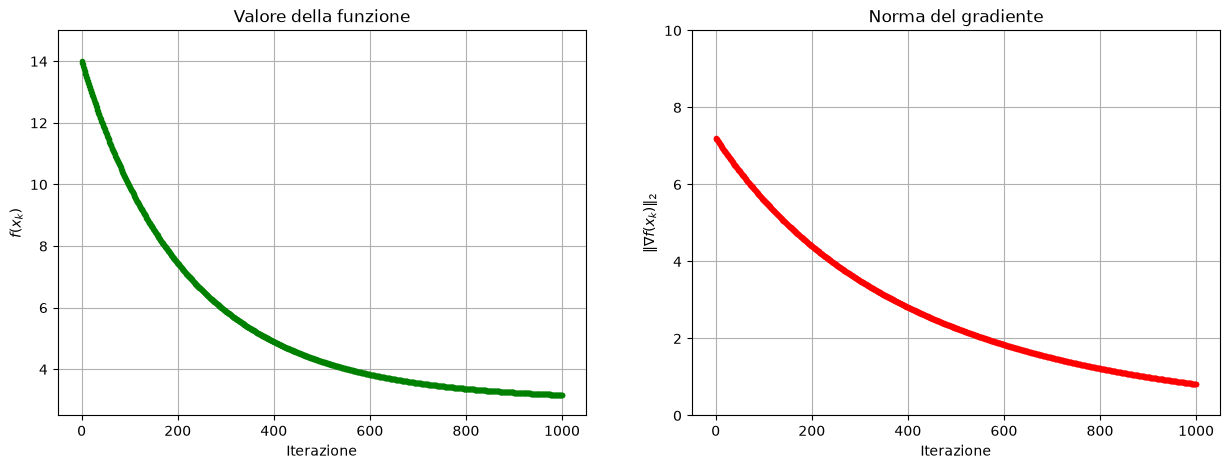

In [96]:
f_values = np.array(hist["f"])
grad_norms = np.array(hist["grad_norm"])

plt.figure(figsize=(15, 5))

# Primo grafico: valori della funzione
plt.subplot(1, 2, 1)
plt.plot(f_values, ".-", color = 'green')
plt.xlabel("Iterazione")
plt.ylabel(r"$f(x_k)$")
plt.ylim([2.5, 15])
plt.title("Valore della funzione")
plt.grid(True)

# Secondo grafico: norma del gradiente
plt.subplot(1, 2, 2)
# plt.semilogy(grad_norms, ".-", color = "red")
plt.plot(grad_norms, ".-", color = "red")
plt.xlabel("Iterazione")
plt.ylabel(r"$\|\nabla f(x_k)\|_2$")
plt.ylim([0, 10])
plt.title("Norma del gradiente")
plt.grid(True)

plt.show()

In [99]:
#### punto 5 ########################

x_start = np.array( [4,-1] )
maxiter = 1000
passo = 0.1
tol = 0.1

x_sol, hist = discesa_gradiente(f, grad_f, x0=x_start, maxit=maxiter, alpha=passo)
# x_sol, hist = discesa_gradiente(f, grad_f, x0=x_start, maxit=maxiter, alpha=passo, tol_grad=tol)
print(x_sol)

errore = np.linalg.norm(x_star-x_sol)
print(f"Errore della soluzione: {errore}")

Convergenza numerica raggiunta in 70 iterazioni.
[ 1.00000049 -2.        ]
Errore della soluzione: 4.93651367339254e-07


In [100]:
#### punto 6 ########################

def discesa_gradiente_bt(
    f,              # funzione obiettivo
    grad_f,         # gradiente della funzione obiettivo
    x0,             # punto iniziale 
    alpha0=1.0,     # lunghezza del passo iniziale, 0<alpha
    rho=0.5,        # fattore di riduzione del passo, 0<rho<1
    c1=1e-4,        # parametro della condizione di Armijo, 0<c1<1
    tau=1e-12,      # lunghezza del minimo passo ammesso, 0<rho<alpha
    tol_grad=1e-6,  # tolleranza sulla norma del gradiente
    maxit=1000      # massimo numero di iterazioni
):
    """
    Discesa del gradiente con backtracking di Armijo.
    """

    # Controlli sugli imput
    if not 0 < rho < 1:
        raise ValueError("rho deve appartenere a (0, 1).")

    if not 0 < c1 < 1:
        raise ValueError("c1 deve appartenere a (0, 1).")

    if not 0 < tau <= alpha0:
        raise ValueError("tau deve essere positivo e non superiore ad alpha0.")

    # Inizializzazioni
    x = np.asarray(x0, dtype=float).copy()

    k = 0
    fx = f(x)
    grad = grad_f(x)
    grad_norm = np.linalg.norm(grad)

    history = {
        "x": [x.copy()],
        "f": [fx],
        "grad_norm": [grad_norm],
        "alpha": []
    }

    # Ciclo iterativo di risoluzione
    while grad_norm > tol_grad and k < maxit:

        # Direzione di discesa
        p = -grad

        # Scelta del passo di discesa
        alpha = alpha0

        while f(x + alpha * p) > fx + c1 * alpha * np.dot(grad, p): # Backtracking di Armijo

            if alpha <= tau:
                print("Passo minimo raggiunto senza soddisfare Armijo.")
                return x, history

            alpha = max(rho * alpha, tau)

        # Aggiornamento dell'iterata
        x = x + alpha * p
        k += 1

        # Aggiornamento delle quantità
        fx = f(x)
        grad = grad_f(x)
        grad_norm = np.linalg.norm(grad)

        # Salvataggio della storia
        history["x"].append(x.copy())
        history["f"].append(fx)
        history["grad_norm"].append(grad_norm)
        history["alpha"].append(alpha)

    if grad_norm <= tol_grad:  # x è punto stazionario
        print(f"Convergenza numerica raggiunta in {k} iterazioni.")
    else:
        print("Raggiunto il numero massimo di iterazioni.")

    return x, history


x_start = np.array( [4,-1] )
maxiter = 1000
alpha_start = 0.001

x_sol, hist = discesa_gradiente_bt(f, grad_f, x0=x_start, maxit=maxiter, alpha0=alpha_start)
print(x_sol)

errore = np.linalg.norm(x_star-x_sol)
print(f"Errore della soluzione: {errore}")

Raggiunto il numero massimo di iterazioni.
[ 1.40519357 -1.98183069]
Errore della soluzione: 0.4056007283311473


In [ ]:
#### punto 7 ########################

x_start = np.array( [4,-1] )
maxiter = 1000
alpha_start = 1

x_sol, hist = discesa_gradiente_bt(f, grad_f, x0=x_start, maxit=maxiter, alpha0=alpha_start)
print(x_sol)

errore = np.linalg.norm(x_star-x_sol)
print(f"Errore della soluzione: {errore}")

Convergenza numerica raggiunta in 2 iterazioni.
[ 1. -2.]
Errore della soluzione: 0.0
